c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


853/853 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.0086


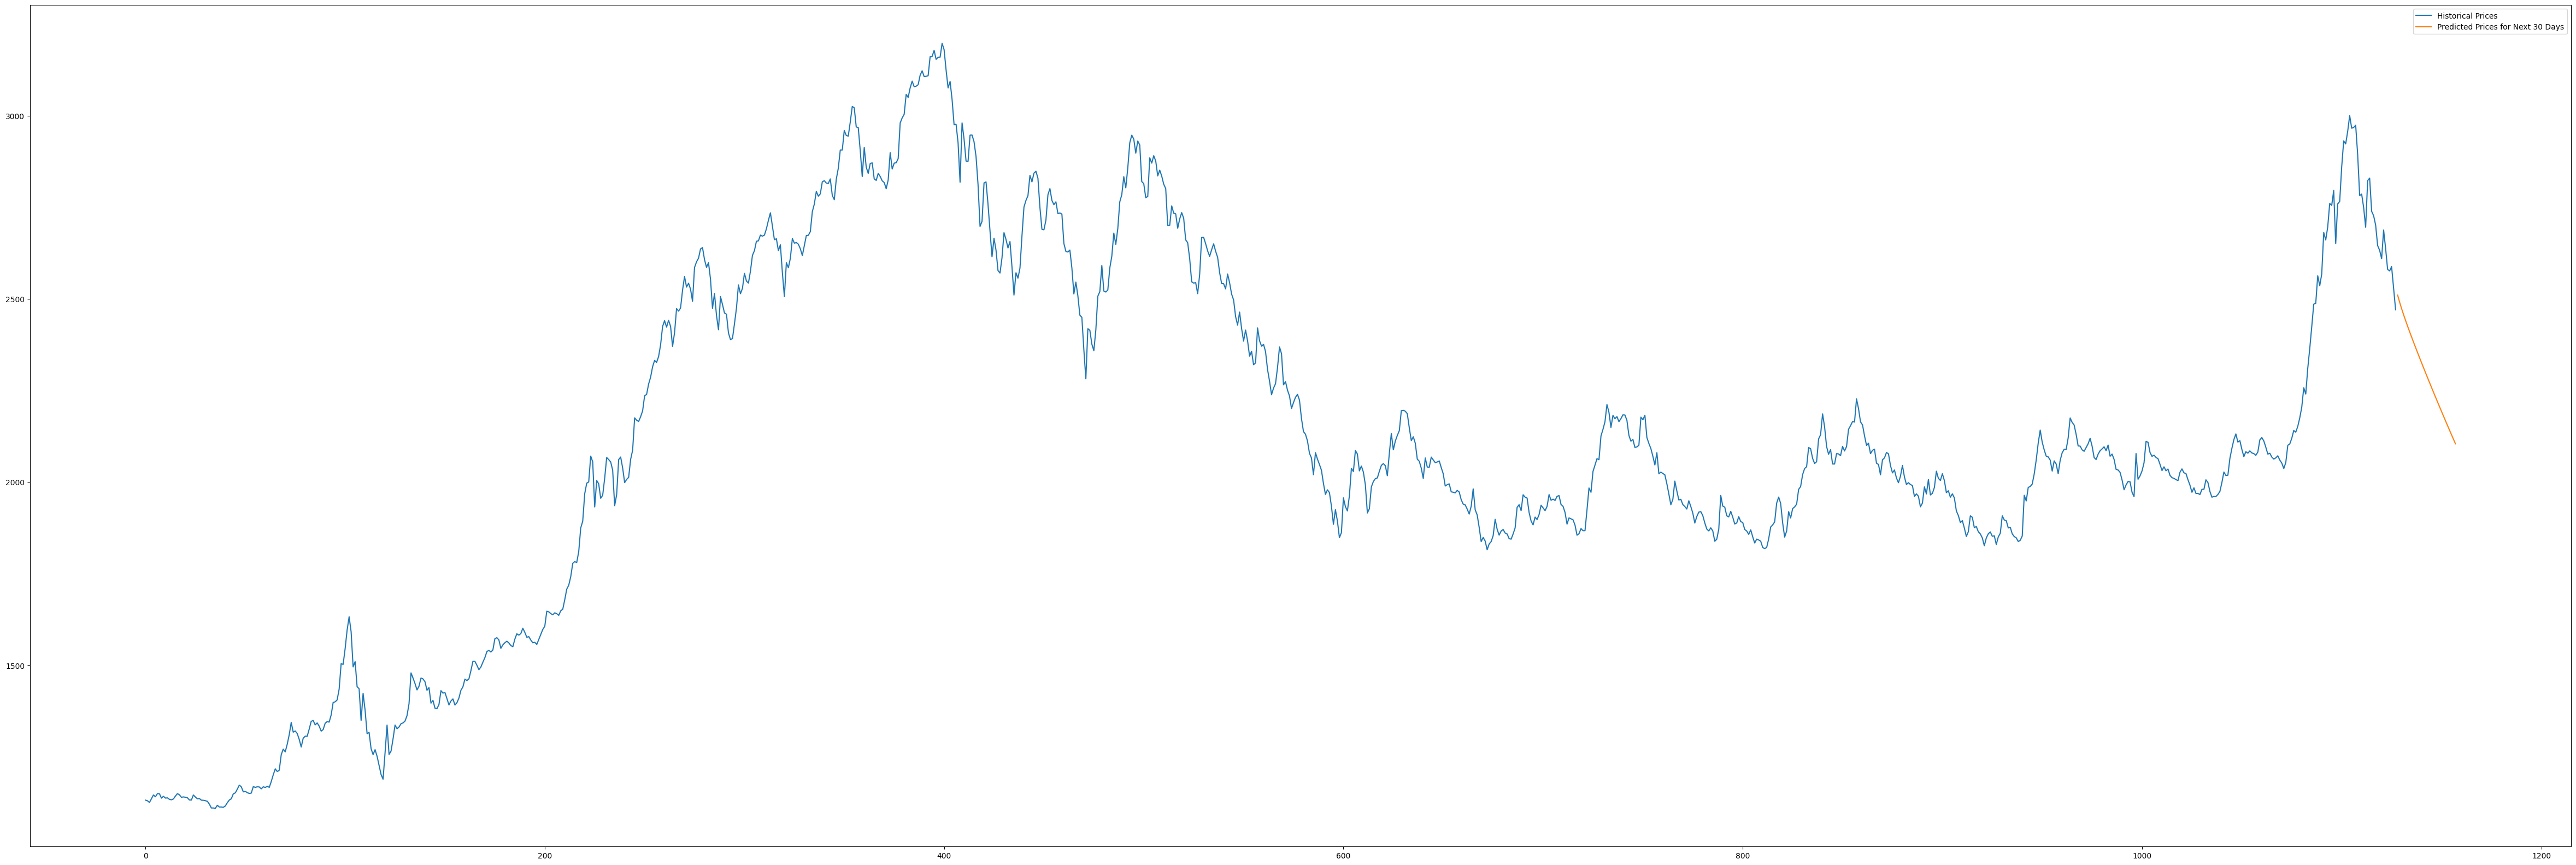

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Load your dataset
data = pd.read_csv('stock_prices.csv')
data = data['Close'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Prepare the data for LSTM
def create_dataset(data, time_step=1):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60  # Number of previous days to consider for prediction
X, Y = create_dataset(scaled_data, time_step)

# Reshape input to be [samples, time steps, features] which is required for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split the data into training and testing sets
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(Y)]

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, Y_train, batch_size=1, epochs=1)

# Predict the next 30 days
last_60_days = scaled_data[-60:]
predicted_prices = []

for _ in range(30):
    X_input = last_60_days[-60:].reshape(1, -1)
    X_input = X_input.reshape((1, time_step, 1))
    pred_price = model.predict(X_input, verbose=0)
    predicted_prices.append(pred_price[0, 0])
    last_60_days = np.append(last_60_days, pred_price)[1:]

# Inverse transform the predicted prices
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

# Plot the results 
plt.figure(figsize=(60, 20))
plt.plot(range(len(data)), data, label='Historical Prices') 
plt.plot(range(len(data), len(data) + 30), predicted_prices, label='Predicted Prices for Next 30 Days')
plt.legend()
plt.show() 